In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
from opentnsim import graph

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr
from opentnsim.vessel_traffic_service import VesselTrafficService
from opentnsim import tidal_accessibility
from opentnsim.tidal_window_constructor import vessel_specifications, \
                                               vertical_tidal_window_specifications, \
                                               vertical_tidal_window_input, \
                                               horizontal_tidal_window_specifications, \
                                               horizontal_tidal_window_method, \
                                               horizontal_tidal_window_input, \
                                               tidal_period, \
                                               accessibility, \
                                               NetworkProperties
from opentnsim.rule_constructor import vessel_characteristics, vessel_direction, vessel_type

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) for plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 0. Define input
vessel

In [2]:
vessel_length = 300
vessel_beam = 40
vessel_draught = 14.0
vessel_speed = 4.5 #m/s

infrastructure

In [3]:
waterway_length = 100000 #meters
waterway_depth = 15 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level)

tide

In [4]:
tidal_period = 12.5 #hours
tidal_range_sea = 2.0 #meters
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqrt(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor

tidal restrictions

In [5]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage_sea = 10.0 #% of draught 
ukc_percentage_canal = 10.0 #% of draught

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static_sea = 0.0 #meters
ukc_static_canal = 0.0 #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa_sea = 0.0 #% of draught
fwa_canal = 0.0 #% of draught

#### 1. Define object classes

In [6]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        tidal_accessibility.HasDraughtRestrictions,
        graph.HasMultiDiGraph,
        opentnsim.core.Identifiable, # allows to give the object a name and a random ID,
        opentnsim.core.Movable,      # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.vessel_properties.VesselProperties,
    ), 
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [7]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [8]:
# starting point (longitude, latitude)
coordinates_sea = (0,0)

# compute the other point 100 km East from Point 0
coordinates_port = geod.fwd(coordinates_sea[0], coordinates_sea[1], 90 ,waterway_length) # East from Point 0

# define nodes with their geographic coordinates
coordinates_waterway = {"Sea": (coordinates_sea[0], coordinates_sea[1]),
                        "Port basin": (coordinates_port[0], coordinates_port[1]),}

In [9]:
# create list of edges
edges = [("Sea", "Port basin"), ("Port basin", "Sea")] # bi-directional edge

In [10]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coordinate in coordinates_waterway.items():
    FG.add_node(name, geometry=Point(coordinate[0], coordinate[1]))

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], geometry=LineString([Point(coordinates_sea),Point(coordinates_port[:-1])]), weight=1, length_m=waterway_length)

In [11]:
opentnsim.graph.plot_graph(FG)

#### Adding hydrodynamics

In [12]:
# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

# create empty hydrodynamic dataset
hydrodynamic_data = xr.Dataset()

In [13]:
tidal_phase_shift = pd.Timedelta(seconds=waterway_length/tidal_propagation_speed)

tidal_water_level_sea = (tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start)/(12.5*pd.Timedelta(hours=1))))
tidal_water_level_port = tidal_amplication*(tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start-tidal_phase_shift)/(12.5*pd.Timedelta(hours=1))))

In [14]:
water_level_data = xr.DataArray(data=[tidal_water_level_sea,tidal_water_level_port],coords={'STATION':FG.nodes,'TIME':time_series})
MBLs = waterway_depth*np.ones(len(time_series))
MBL_data = xr.DataArray(data=[MBLs,MBLs],coords={'STATION':FG.nodes,'TIME':time_series})
hydrodynamic_data['Water level'] = water_level_data
hydrodynamic_data['MBL'] = MBL_data

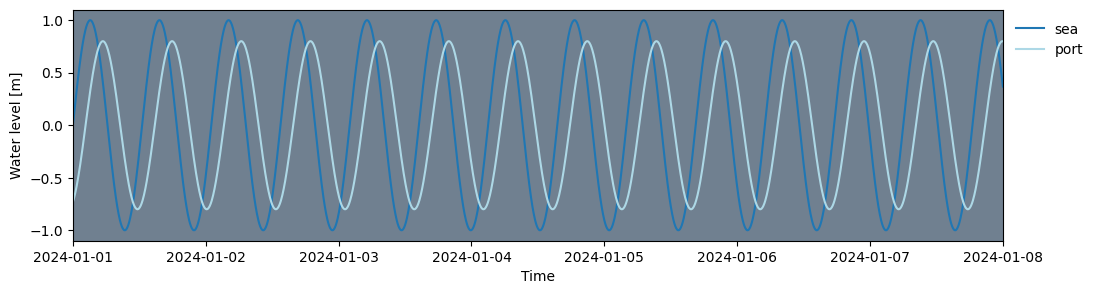

In [15]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategrey')
ax.plot(time_series,tidal_water_level_sea,color='C0',label='sea')
ax.plot(time_series,tidal_water_level_port,color='lightblue',label='port')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(time_series[0],time_series[-1])
ax.legend(loc='upper right',frameon=False,bbox_to_anchor=[1.1,1.0]);

In [16]:
ukc_p = [ukc_percentage_sea/100,ukc_percentage_canal/100] #percentage of the UKC (10% of draught is common)
ukc_s = [ukc_static_sea,ukc_static_canal] #static value of the UKC
fwa = [fwa_sea/100,fwa_canal/100] #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(FG.nodes):
    FG.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(FG,node,vertical_tidal_window_inputs)

#### 3. Run simulation

In [17]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

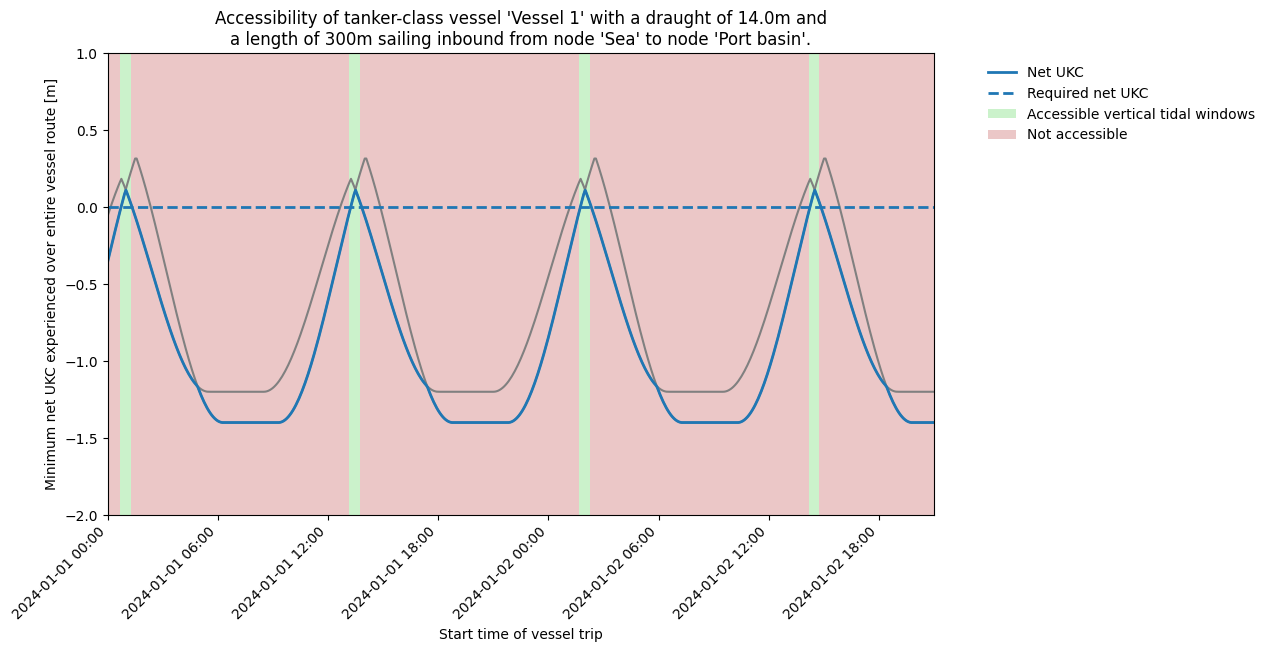

In [18]:
# start simpy environment
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start
env.vessel_traffic_service = VesselTrafficService(hydrodynamic_data = hydrodynamic_data)

# add graph to environment
env.graph = FG

# create vessel from a dict 
path = nx.dijkstra_path(env.graph, "Sea", "Port basin")
data_vessel = {
    "env": env,                                       # needed for simpy simulation
    "name": "Vessel 1",                               # required by Identifiable
    "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
    "route": path,                                    # required by Routeable
    "v": vessel_speed,                                # required by Movable, 1 m/s to check if the distance is covered in the expected time
    "type":"tanker",
    "L":vessel_length,
    "B":vessel_beam,
    "T":vessel_draught,
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
vessel.mission = env.process(mission(env, vessel))
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [19]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

if not df.empty:
    trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
else:
    print("The port was not accessible for vessel")
print('')
print('')

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Waiting for tidal window start,2024-01-01 00:00:00.000000,0.0,POINT (0 0)
1,Waiting for tidal window stop,2024-01-01 00:40:00.000000,0.0,POINT (0 0)
2,Sailing from node Sea to node Port basin start,2024-01-01 00:40:00.000000,0.0,POINT (0 0)
3,Sailing from node Sea to node Port basin stop,2024-01-01 06:50:22.222222,100000.0,POINT (0.8983152841195217 0)


'Vessel 1' travelled a distance of 100000.0 meters
'Vessel 1' took 24622.2 seconds to arrive at its destination
'Vessel 1' travelled at an average speed of 4.1 meters per second


